# Notebook 1: Exploratory Data Analysis
**Brain Tumor MRI Classification — PyTorch Version**

Covers:
- GPU check (PyTorch + CUDA)
- Class distribution
- Sample image visualization
- Image size statistics
- Pixel intensity distribution

## 0. Setup & GPU Check

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch

# ── GPU check ────────────────────────────────────────────────────
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {DEVICE}')

# ── Paths ─────────────────────────────────────────────────────────
TRAIN_DIR    = Path('data/Training')
TEST_DIR     = Path('data/Testing')
CLASSES      = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_LABELS = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
COLORS       = ['#4361EE', '#F72585', '#4CC9F0', '#7209B7']

os.makedirs('results', exist_ok=True)
plt.rcParams['figure.dpi'] = 120
print('Setup complete.')

PyTorch version : 2.6.0+cu124
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM            : 6.4 GB
Using device    : cuda
Setup complete.


## 1. Class Distribution

Train: {'glioma': 826, 'meningioma': 822, 'notumor': 395, 'pituitary': 827} | Total: 2870
Test:  {'glioma': 100, 'meningioma': 115, 'notumor': 105, 'pituitary': 74} | Total: 394


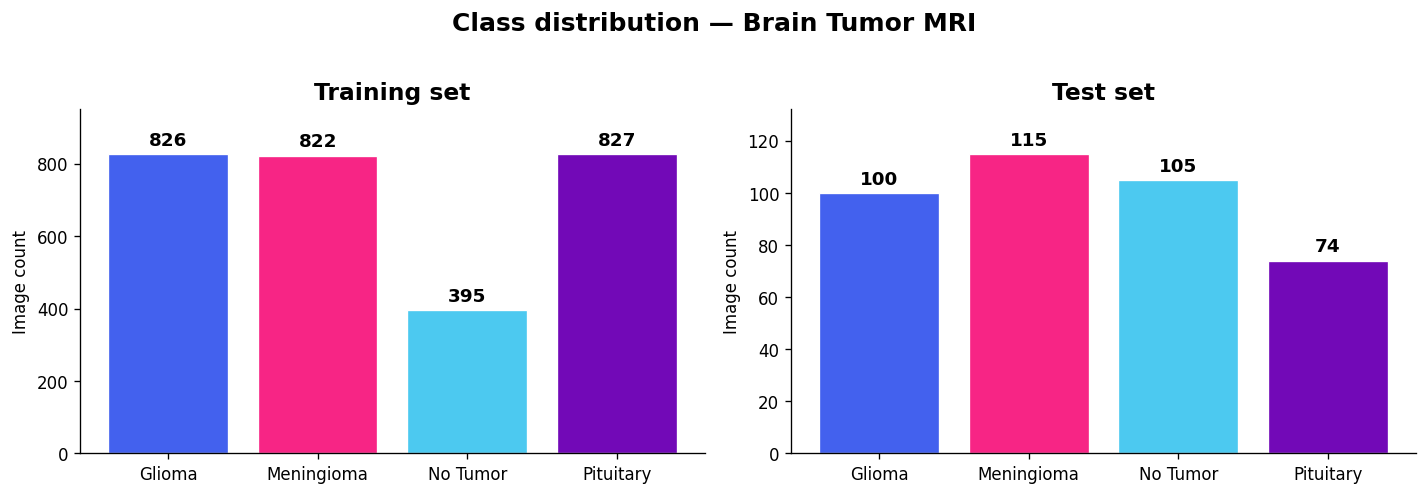

In [2]:
def count_images(base_dir):
    return {cls: len(list((base_dir / cls).glob('*.jpg')) +
                      list((base_dir / cls).glob('*.png')))
            for cls in CLASSES}

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('Train:', train_counts, '| Total:', sum(train_counts.values()))
print('Test: ', test_counts,  '| Total:', sum(test_counts.values()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training set', 'Test set']):
    bars = ax.bar(CLASS_LABELS, counts.values(), color=COLORS, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, padding=3, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Image count')
    ax.set_ylim(0, max(counts.values()) * 1.15)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Class distribution — Brain Tumor MRI', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/class_distribution.png', bbox_inches='tight')
plt.show()

## 2. Sample Images Per Class

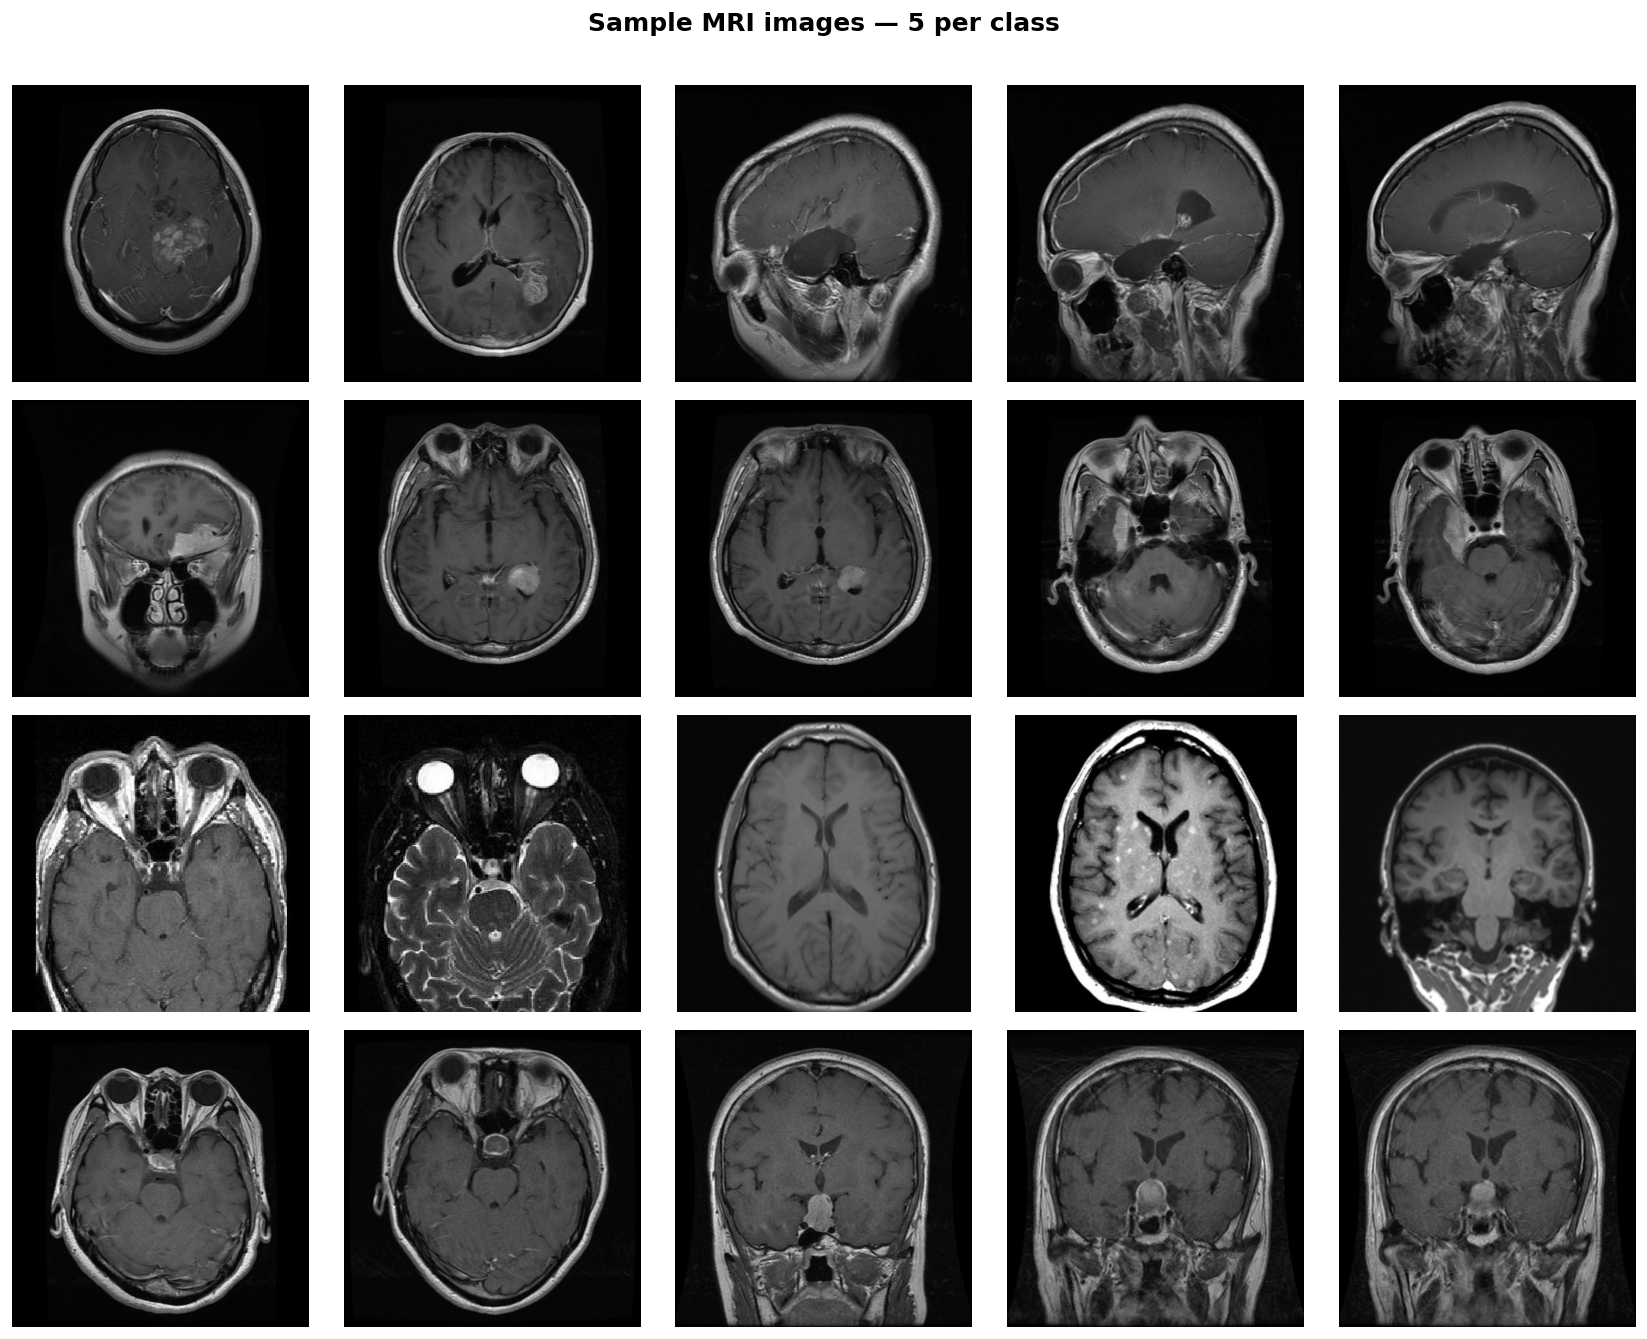

In [3]:
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Sample MRI images — 5 per class', fontsize=15, fontweight='bold', y=1.01)

for row_idx, (cls, label) in enumerate(zip(CLASSES, CLASS_LABELS)):
    img_paths = list((TRAIN_DIR / cls).glob('*.jpg'))[:5]
    for col_idx, img_path in enumerate(img_paths):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_ylabel(
                label, fontsize=12, fontweight='bold',
                labelpad=10, color=COLORS[row_idx]
            )

plt.tight_layout()
plt.savefig('results/sample_images.png', bbox_inches='tight')
plt.show()

## 3. Image Size Statistics

In [4]:
shapes = []
for cls in CLASSES:
    for p in list((TRAIN_DIR / cls).glob('*.jpg'))[:50]:
        img = cv2.imread(str(p))
        if img is not None:
            shapes.append(img.shape[:2])

if shapes:
    heights, widths = zip(*shapes)
    print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')
    print(f'Width  — min: {min(widths)},  max: {max(widths)},  mean: {np.mean(widths):.0f}')
else:
    print('No images found — check TRAIN_DIR path.')
print('All images will be resized to 224x224 for model input.')

Height — min: 198, max: 1365, mean: 499
Width  — min: 201,  max: 1365,  mean: 497
All images will be resized to 224x224 for model input.


## 4. Pixel Intensity Distribution

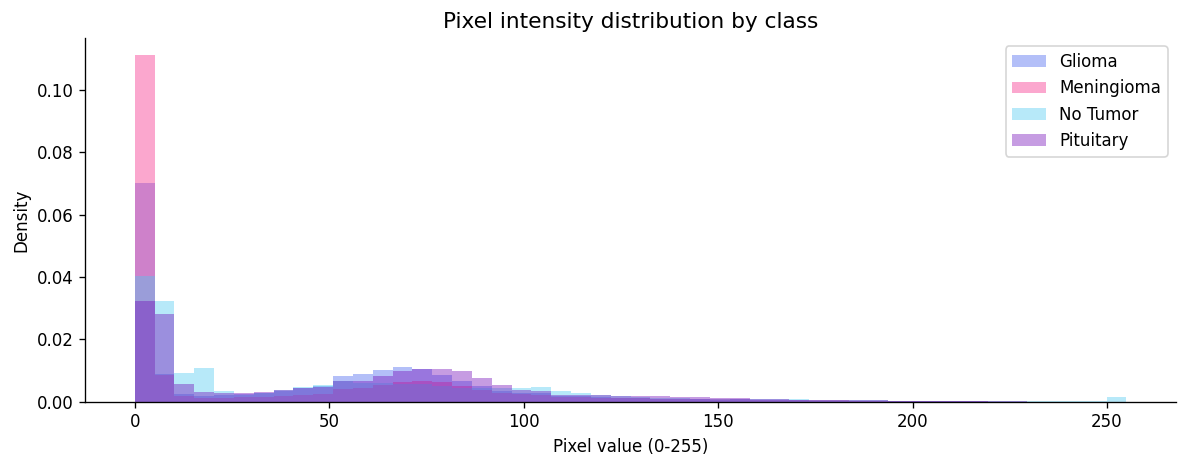

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in zip(CLASSES, CLASS_LABELS, COLORS):
    pixel_vals = []
    for p in list((TRAIN_DIR / cls).glob('*.jpg'))[:30]:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixel_vals.extend(img.flatten().tolist())
    ax.hist(pixel_vals, bins=50, alpha=0.4, color=color,
            label=label, density=True)

ax.set_title('Pixel intensity distribution by class', fontsize=13)
ax.set_xlabel('Pixel value (0-255)')
ax.set_ylabel('Density')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/pixel_distribution.png', bbox_inches='tight')
plt.show()

## 5. Mean Image per Class & Feature Separability

Two deeper views of the data, beyond raw counts and sample montages:

- **Mean image per class** — the per-pixel average of every (preprocessed) training
  image in a class. It exposes the *consistent spatial structure* a model can latch
  onto: where each tumour type tends to sit and how much the preprocessing
  (brain-crop + CLAHE) standardises framing across scanners.
- **t-SNE of HOG features** — a 2-D projection of classical texture/edge descriptors.
  Visible clusters here mean the task is *partly separable before any deep learning* —
  a sanity check on the data and a yardstick for how much the CNN must add.

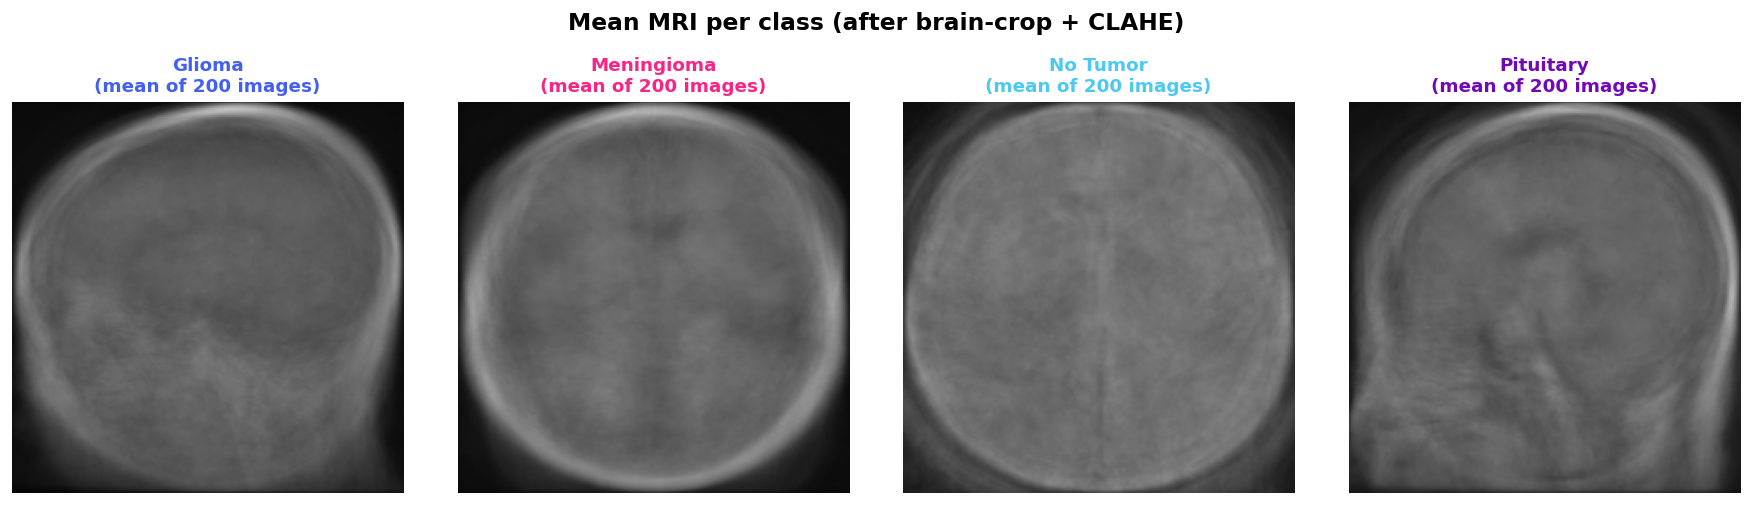

Saved: results/mean_image_per_class.png


In [6]:
import sys
from pathlib import Path
if 'src' not in sys.modules:
    _root = Path.cwd()
    if not (_root / 'src').exists() and (_root.parent / 'src').exists():
        _root = _root.parent
    sys.path.insert(0, str(_root))
from src.preprocessing import MRIPreprocess
from PIL import Image

prep = MRIPreprocess(use_crop=True, use_clahe=True)   # same pipeline the model sees
MEAN_SIZE = 224
N_PER_CLASS = 200          # cap per class for speed; set to None to use all

def class_image_paths(cls):
    return (list((TRAIN_DIR / cls).glob('*.jpg')) +
            list((TRAIN_DIR / cls).glob('*.png')))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, cls, label, color in zip(axes, CLASSES, CLASS_LABELS, COLORS):
    paths = class_image_paths(cls)
    if N_PER_CLASS:
        paths = paths[:N_PER_CLASS]
    acc, n = np.zeros((MEAN_SIZE, MEAN_SIZE, 3), dtype=np.float64), 0
    for p in paths:
        img = prep(Image.open(p)).resize((MEAN_SIZE, MEAN_SIZE))
        acc += np.asarray(img, dtype=np.float64)
        n += 1
    mean_img = (acc / max(n, 1)).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(f'{label}\n(mean of {n} images)', fontsize=11,
                 fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('Mean MRI per class (after brain-crop + CLAHE)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('results/mean_image_per_class.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: results/mean_image_per_class.png')

HOG matrix: (200, 8100)  (50 samples x 4 classes)


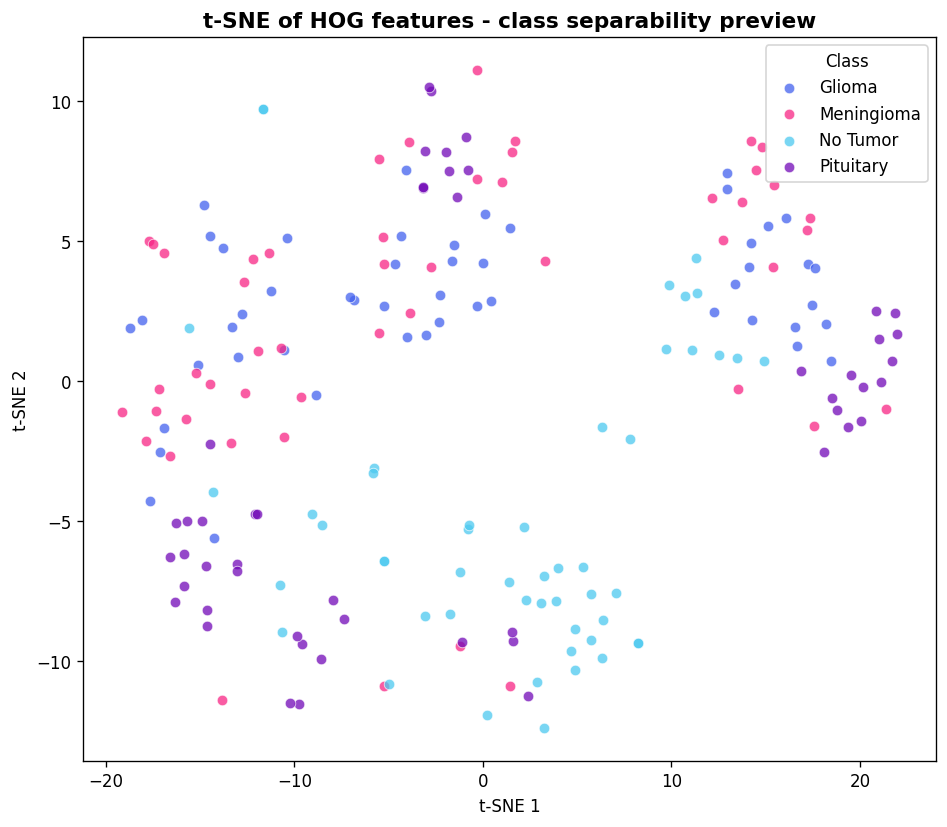

Saved: results/tsne_hog_features.png


In [7]:
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

HOG_SIZE = 128
SAMPLES_PER_CLASS = 50

def hog_features(pil_img):
    g = np.asarray(pil_img.convert('L').resize((HOG_SIZE, HOG_SIZE)))
    return hog(g, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), block_norm='L2-Hys')

X, y = [], []
rng = np.random.default_rng(42)
for ci, cls in enumerate(CLASSES):
    paths = class_image_paths(cls)
    rng.shuffle(paths)
    for p in paths[:SAMPLES_PER_CLASS]:
        X.append(hog_features(prep(Image.open(p))))
        y.append(ci)
X, y = np.array(X), np.array(y)
print(f'HOG matrix: {X.shape}  ({SAMPLES_PER_CLASS} samples x {len(CLASSES)} classes)')

# Same HOG descriptor pt_02 feeds its SVM, so this previews that
# exact feature space. PCA -> 50 dims (denoise + speed), then t-SNE 2-D.
X_pca = PCA(n_components=50, random_state=42).fit_transform(X)
X_2d  = TSNE(n_components=2, perplexity=30, init='pca',
             random_state=42).fit_transform(X_pca)

fig, ax = plt.subplots(figsize=(8, 7))
for ci, label in enumerate(CLASS_LABELS):
    m = y == ci
    ax.scatter(X_2d[m, 0], X_2d[m, 1], s=40, alpha=0.75,
               color=COLORS[ci], edgecolors='white', linewidths=0.5, label=label)
ax.set_title('t-SNE of HOG features - class separability preview',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(title='Class')
plt.tight_layout()
plt.savefig('results/tsne_hog_features.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: results/tsne_hog_features.png')

## 6. Key EDA Observations

- **Total images**: ~3,264 train, ~394 test
- **Class imbalance**: No Tumor has ~half the samples of others — use class weights in training
- **Image sizes**: Variable — must resize to 224×224
- **Pixel intensity**: MRI scans are predominantly dark with bright tumor regions

**Next**: Notebook 02 builds the SVM baseline.